# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [26]:
#pip install wordcloud
import pandas as pd

df = pd.read_csv("superheroes.csv")
print(df.head())
print(df.info())
print(df.loc[22, "name"])
print(df.loc[22, "relatives"])

            name               real_name               full_name  \
0        3-D Man     Delroy Garrett, Jr.     Delroy Garrett, Jr.   
1  514A (Gotham)             Bruce Wayne                     NaN   
2         A-Bomb  Richard Milhouse Jones  Richard Milhouse Jones   
3             Aa                      Aa                     NaN   
4     Aaron Cash              Aaron Cash              Aaron Cash   

  overall_score                                       history_text  \
0             6  Delroy Garrett, Jr. grew up to become a track ...   
1            10  He was one of the many prisoners of Indian Hil...   
2            20   Richard "Rick" Jones was orphaned at a young ...   
3            12  Aa is one of the more passive members of the P...   
4             5  Aaron Cash is the head of security at Arkham A...   

                                         powers_text  intelligence_score  \
0                                                NaN                  85   
1                 

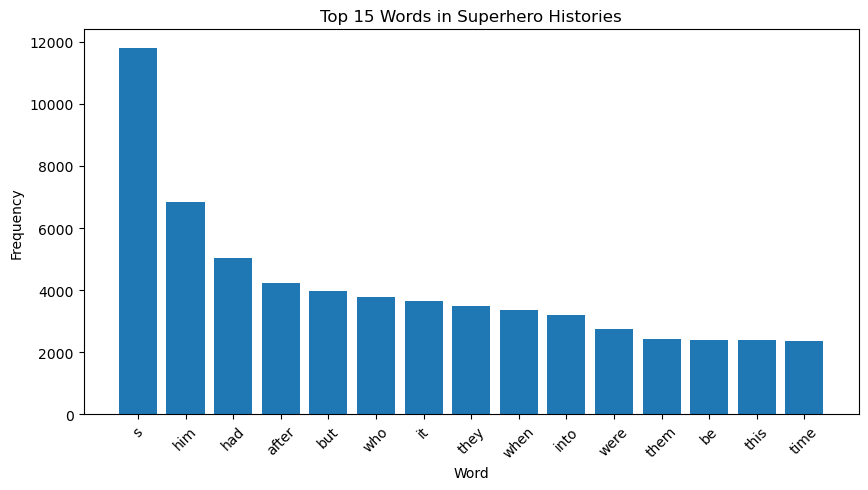

In [29]:
from collections import Counter
import re

text = " ".join(df["history_text"].dropna()).lower()

words = re.findall(r'\b[a-z]+\b', text)

stopwords = {
    'the','and','of','to','a','in','was','is',
    'for','that','with','as','on','his','her',
    'he','she','at','by','from','their','an'
}

words = [w for w in words if w not in stopwords]

word_counts = Counter(words)

top_words = word_counts.most_common(15)

labels = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

plt.figure(figsize=(10,5))
plt.bar(labels, counts)
plt.xticks(rotation=45)
plt.title("Top 15 Words in Superhero Histories")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.show()

The word cloud shows the most frequently used words in the origin stories. The larger the word, the more frequently used. Words like power, time, battle, and Earth, seem to be a common theme among super heros.

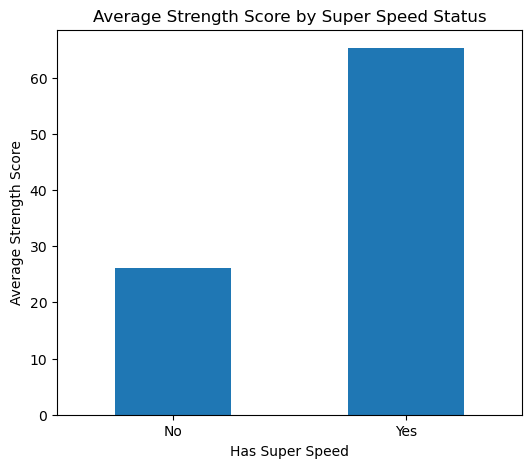

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

avg_strength = df.groupby("has_super_speed")["strength_score"].mean()

avg_strength.index = ["No", "Yes"]

plt.figure(figsize=(6,5))
avg_strength.plot(kind="bar")

plt.title("Average Strength Score by Super Speed Status")
plt.xlabel("Has Super Speed")
plt.ylabel("Average Strength Score")
plt.xticks(rotation=0)
plt.show()

This bar graph represents the superspeed status against the average strenght. There seems to be a strong correlation betweet super speed and higher strength. 

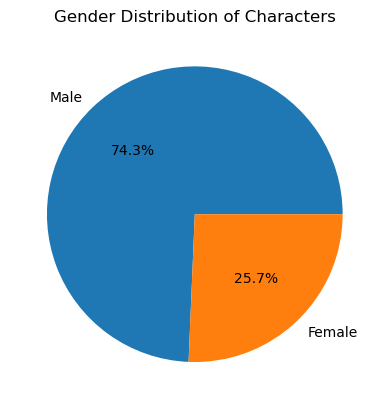

In [32]:
df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Characters")
plt.ylabel("")
plt.show()

This pie graph represents the percentage of male vs male superheroes. Males seem to hold dominance in this category. The list contiains approximately 3/4 male and 1/4 female. 